In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging
import sys

from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from scripts import (
    generate_dataset,
    optuna_search,
    predictions,
    training,
)
from experiments.plotting import _plot_SRE_distribution, view_correlation

from src.utils import configure_logger
from GNN.training.utils import to_scalar
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from GNN.training.utils import collect_dataset_indices
from GNN.physics_aware_NN import ShardedQuantumCircuitGraphDataset

In [4]:
logger = logging.getLogger(__name__)
configure_logger(logging.INFO, logging.INFO)

True

In [5]:
def dataset_to_dataframe(dataset):
    data = []
    keep_fields = ["n_qubits", "n_layers", "sre", "seed", "family"]
    for item in dataset:
        row = {}
        for field in keep_fields:
            if not hasattr(item, field):
                continue

            value = getattr(item, field)
            if field == "family":
                # Keep categorical label as text (e.g., "clifford")
                row[field] = str(value)
            else:
                row[field] = to_scalar(value)
        data.append(row)

    df = pd.DataFrame(data)

    int_cols = ["n_qubits", "n_layers", "seed"]
    for col in int_cols:
        if col in df.columns:
            df[col] = df[col].astype(int)

    float_cols = ["sre"]
    for col in float_cols:
        if col in df.columns:
            df[col] = df[col].astype(float)

    if "family" in df.columns:
        df["family"] = df["family"].astype(str)

    return df

In [6]:
target_variant = "sre"
family = "random"
# regime_type = "identity_like"
regime_type = "saturated"

index_path = collect_dataset_indices(
    "../outputs/data/datasets_SRE",
    family=family,
)
print(f"Collected {len(index_path)} dataset indices for family '{family}' and regime '{regime_type}'")
base_dataset = ShardedQuantumCircuitGraphDataset(
    index_paths=index_path,
    target_variant=target_variant,
    split="all",
    cache_size=64,
)
df = dataset_to_dataframe(base_dataset)

plot_df = df[
    (df["sre"].notna())
]

avg_df = (
    plot_df
    .groupby(["n_qubits", "n_layers", "family"])
    .agg(
        sre_mean=("sre", "mean"),
        sre_std=("sre", "std"),
    )
    .reset_index()
)

avg_df.to_csv(f"final/data/avg_sre_{family}.csv", index=False)

Collected 1 dataset indices for family 'random' and regime 'saturated'
Detected node feature dims: [17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41, 43]
Detected global feature dims: [26775, 267750]


In [7]:
df.head()

,n_qubits,n_layers,sre,seed,family
0,4,1,0.202442,22550440,random
1,4,1,0.000129,25064164,random
2,4,1,0.682258,35019855,random
3,4,1,0.412548,35413194,random
4,4,1,0.374010,42486639,random


In [8]:
df_random = df[df["family"] == "random"].copy()
print(df_random["sre"].describe())
print("target_variant:", df_random["sre"].var())
print("Std:", df_random["sre"].std())

df_random.groupby("n_qubits")["sre"].agg(
    ["count", "mean", "std", "var"],
)

count    3.570000e+04
mean     3.400162e+00
std      2.365550e+00
min     -2.562741e-15
25%      1.638032e+00
50%      3.153243e+00
75%      5.348991e+00
max      8.013436e+00
Name: sre, dtype: float64
target_variant: 5.595829062325704
Std: 2.365550477653289


,count,mean,std,var
n_qubits,,,,
4,8925,1.631783,0.821712,0.675211
6,8925,2.799404,1.459088,2.128938
8,8925,3.984315,2.131372,4.542746
10,8925,5.185146,2.832321,8.022040
12,0,NaN,NaN,NaN
14,0,NaN,NaN,NaN
16,0,NaN,NaN,NaN
18,0,NaN,NaN,NaN
20,0,NaN,NaN,NaN


In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_true = predictions_df["true"].to_numpy()
y_pred = predictions_df["pred"].to_numpy()

mean_pred = np.full_like(y_true, y_true.mean())

print("Model MSE:", mean_squared_error(y_true, y_pred))
print("Mean baseline MSE:", mean_squared_error(y_true, mean_pred))

print("Model MAE:", mean_absolute_error(y_true, y_pred))
print("Mean baseline MAE:", mean_absolute_error(y_true, mean_pred))

print("Model R2:", r2_score(y_true, y_pred))

NameError: name 'predictions_df' is not defined

### Training

In [41]:
model_type="gnn"
epochs = 10
lr = 1.5131621801102364e-05
loss_type = "huber"   # "mse" | "huber"
batch_size = 16
training_mode = "per_family"  # "global" | "per_family"
family = "haar"  # required if training_mode == "per_family"
target = "sre"
training_data_dir = "../outputs/data/datasets_SRE"
target_variant = "sre_density"  # "sre" | "sre_density" | "log_sre" | "sqrt_sre"
model_save_path = f"../notebooks/outputs/models/final/{family}_model_{model_type}_{training_mode}_{target_variant}.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
training_scope = "family" if training_mode == "per_family" else "global"
plot_qubits = 6
plot_layers = 100

split = "target"  # "target" | "family"

In [42]:
training(
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    target_variant=target_variant,
    model_type=model_type,
    model_hparams=None,
    train_hparams=None,
    training_data_dir=training_data_dir,
    split=split,
    model_save_path=model_save_path,
    show_progress=True,
    show_val_progress=False,
    log_every_n_batches=10,
    heartbeat_secs=60.0,
    epoch_time_warning_secs=600.0,
)

2026-06-23 15:19:23,769 - GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=per_family | family=haar | loss_type=huber
2026-06-23 15:19:23,779 - GNN.training.runners - INFO - Training configuration done.
2026-06-23 15:19:23,780 - GNN.training.runners - INFO - Collecting data paths...
2026-06-23 15:19:23,789 - GNN.training.runners - INFO - Found 1 data paths.
2026-06-23 15:19:23,789 - GNN.training.runners - INFO - Data paths collected.
2026-06-23 15:19:23,791 - GNN.training.runners - INFO - Building loaders and model for model_type=gnn...


Detected node feature dims: [17, 19, 21, 23]
Detected global feature dims: [9275, 92750]


2026-06-23 15:20:31,549 - GNN.training.runners - INFO - Loaders and model built.
2026-06-23 15:20:31,550 - GNN.training.runners - INFO - Starting training...
2026-06-23 15:20:31,552 - GNN.training.train - INFO - Using device: cuda
2026-06-23 15:20:31,621 - GNN.training.train - INFO - -------- EPOCH 001 --------


Epoch 1/10:  66%|██████▌   | 1062/1607 [01:00<00:24, 22.27it/s, loss=0.0296, graphs=17040]

2026-06-23 15:21:31,665 - GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 1065/1607 | loss 0.029591 | elapsed 60.0s | graphs 17040


...

2026-06-23 15:33:52,300 - GNN.training.train - INFO - Training complete (82.5s) | running validation...


2026-06-23 15:33:59,446 - GNN.training.train - INFO - Losses | train 0.026023 | val 0.025118 | lr 5.46e-04 | time train=82.5s val=7.1s total=89.6s
2026-06-23 15:33:59,449 - GNN.training.train - INFO - -------- EPOCH 010 --------


Epoch 10/10:  71%|███████   | 1142/1607 [01:00<00:28, 16.20it/s, loss=0.0261, graphs=18304]

2026-06-23 15:34:59,511 - GNN.training.train - INFO - [Heartbeat] Epoch 10 batch 1144/1607 | loss 0.026110 | elapsed 60.1s | graphs 18304


2026-06-23 15:35:23,283 - GNN.training.train - INFO - Training complete (83.8s) | running validation...
2026-06-23 15:35:30,476 - GNN.training.train - INFO - Losses | train 0.026076 | val 0.025961 | lr 5.46e-04 | time train=83.8s val=7.2s total=91.0s
2026-06-23 15:37:22,035 - GNN.training.runners - INFO - Training complete.
2026-06-23 15:37:22,210 - experiments.plotting - INFO - Saved training curve plot to outputs\figures\training_curves\training_curves_gnn_huber_haar_3.png
2026-06-23 15:37:22,244 - GNN.training.runners - INFO - Saved model checkpoint to ..\notebooks\outputs\models\final\haar_model_gnn_per_family_sre_density.pt
2026-06-23 15:37:22,410 - scripts.train_model - INFO - Final test loss: 0.025757
2026-06-23 15:37:22,412 - scripts.train_model - INFO - Test R2 score: 0.1831
2026-06-23 15:37:22,413 - scripts.train_model - INFO - Validation R2 score: 0.1762
2026-06-23 15:37:22,413 - scripts.train_model - INFO - Training R2 score: 0.1894


In [43]:
training_scope = "family" if training_mode == "per_family" else "global"
model_save_path = model_save_path
batch_size = 16
predictions(
    model_path=model_save_path,
    model_kind=model_type,
    training_scope=training_scope,
    target_variant=target_variant,
    loss_type=loss_type,
    model_family=family,
    dataset_root=training_data_dir,
    dataset_family=family,
    batch_size=batch_size,
    global_feature_variant="binned",
    node_feature_backend_variant=None,
    plot_n_layers=plot_layers,
    plot_n_qubits=plot_qubits,
    split_by_family=True,
    show_progress=True,
)

2026-06-23 15:37:24,057 - scripts.predictions - INFO - Loading checkpoint: ../notebooks/outputs/models/final/haar_model_gnn_per_family_sre_density.pt
2026-06-23 15:37:24,066 - scripts.predictions - INFO - Using target_variant from checkpoint: sre_density
2026-06-23 15:37:24,084 - scripts.predictions - INFO - Found 1 prediction files


Detected node feature dims: [17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41, 43]
Detected global feature dims: [9275, 92750]
=== Prediction dataset sample ===
target_variant: sre_density
x: torch.Size([12, 43])
global_features: torch.Size([1, 92750])
y: tensor([-0.])
sre: tensor([-0.])
raw_sre: tensor([-0.])
n_qubits: tensor([4])
node_in_dim checkpoint: 13
global_in_dim checkpoint: 2
family_projection: haar
all_gate_keys len: 0


Predicting (gnn): 100%|██████████| 7810/7810 [06:30<00:00, 20.01batch/s]
2026-06-23 15:44:47,130 - scripts.predictions - INFO - Saved 124950 predictions to outputs/predictions/family/gnn_predictions_haar.csv


In [44]:
plot_qubits = 8
plot_layers = 40
family = "haar"
df = pd.read_csv(f"outputs/predictions/family/gnn_predictions_{family}.csv")
# df = pd.read_csv(f"../notebooks/final/predictions/gnn_predictions_{family}.csv")
cols_to_fix = ["n_qubits", "n_layers", "seed"]

for col in cols_to_fix:
    df[col] = df[col].apply(to_scalar).astype(int)

new_df = df[(df["n_qubits"] == plot_qubits) & (df["n_layers"] == plot_layers)]

print(new_df["target_sre"].describe())
print(new_df["predicted_sre"].describe())

count    175.000000
mean       0.465865
std        0.259694
min       -0.000000
25%        0.268075
50%        0.535044
75%        0.698424
max        0.754045
Name: target_sre, dtype: float64
count    175.000000
mean       0.898831
std        0.101429
min        0.680993
25%        0.823758
50%        0.908006
75%        0.994181
max        1.070015
Name: predicted_sre, dtype: float64


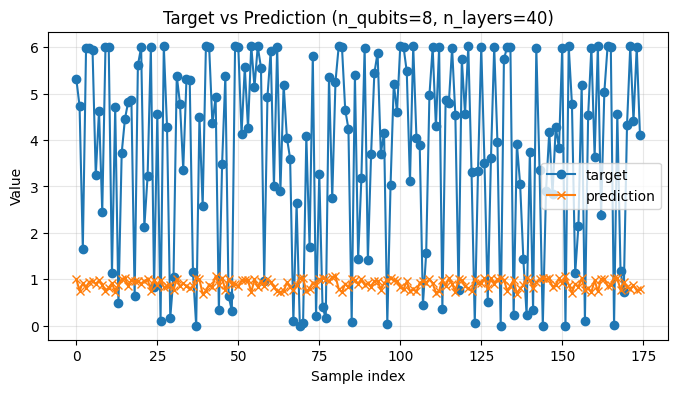

Pearson r = -0.2560


Text(0.5, 1.0, 'True vs Predicted SRE for Quansistor Family (GNN Model)')

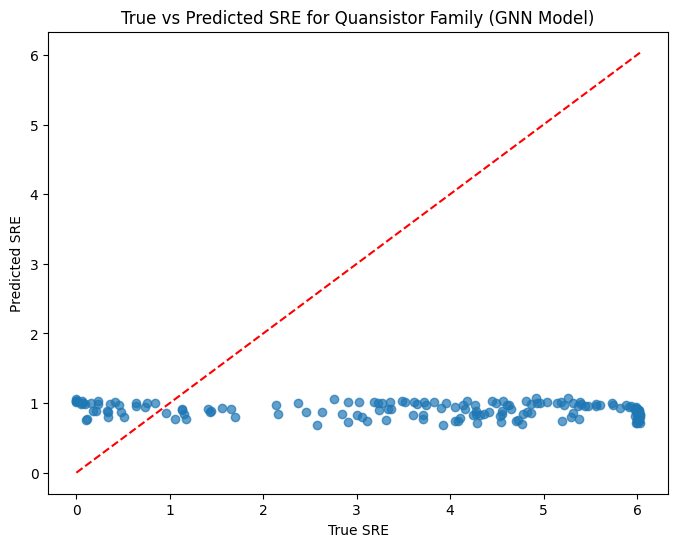

In [45]:
nq=plot_qubits
nl=plot_layers

df["target_sre"] = df["target_sre"] * nq

view_correlation(
    df,
    nq=plot_qubits,
    nl=plot_layers,
    col_x="target_sre",
    col_y="predicted_sre",
)
df = df[(df["n_qubits"] == plot_qubits) & (df["n_layers"] == plot_layers)]
plt.figure(figsize=(8, 6))
plt.scatter(df["target_sre"], df["predicted_sre"], alpha=0.7)
plt.plot([df["target_sre"].min(), df["target_sre"].max()], [df["target_sre"].min(), df["target_sre"].max()], "r--")  # y=x line
plt.xlabel("True SRE")
plt.ylabel("Predicted SRE")
plt.title("True vs Predicted SRE for Quansistor Family (GNN Model)")